# 02_Quantum_Fragment_Descriptors_and_Full_Ablation
## Real executable code — Materia Arche V3.2
### Builds quantum descriptors + runs full 3-arm ablation

In [1]:
# 1. Install requirements (run once)
!pip install pandas numpy scipy scikit-learn pennylane matplotlib -q

import pandas as pd
import numpy as np
from scipy.stats import kendalltau
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import pennylane as qml
import matplotlib.pyplot as plt

print("✅ Libraries loaded")

zsh:1: command not found: pip


✅ Libraries loaded


/Users/johnodowd/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# 2. Load the clean dataset from Notebook 01
df = pd.read_csv("perovskite_stability_clean.csv")
print(f"✅ Loaded {len(df)} devices for ablation")

# Classical composition features
classical_features = ['Perovskite_band_gap', 'Pb', 'Sn', 'I', 'Br', 'Cl',
                      'MA', 'FA', 'Cs']

# Full ML features (composition + process)
ml_features = classical_features + [
    'first_Prvskt_annealing_temperature', 'first_Prvskt_thermal_annealing_time',
    'Perovskite_thickness', 'Cell_area_measured', 'JV_default_Voc',
    'JV_default_Jsc', 'JV_default_FF'
]

X_classical = df[classical_features].fillna(0)
X_ml = df[ml_features].fillna(0)
y = np.log1p(df['Stability_PCE_T80'])

# Frozen split (same seed as Notebook 01)
X_train_c, X_test_c, y_train, y_test = train_test_split(X_classical, y, test_size=0.2, random_state=42)
X_train_ml, X_test_ml, _, _ = train_test_split(X_ml, y, test_size=0.2, random_state=42)

✅ Loaded 1543 devices for ablation


## ARM A: Classical descriptors only

In [3]:
rf_classical = RandomForestRegressor(n_estimators=100, random_state=42)
rf_classical.fit(X_train_c, y_train)
pred_classical = rf_classical.predict(X_test_c)
tau_classical, p_classical = kendalltau(y_test, pred_classical)
mae_classical = mean_absolute_error(y_test, pred_classical)
print(f"Arm A (Classical) — Kendall tau-b: {tau_classical:.3f}, MAE: {mae_classical:.3f}, p={p_classical:.2e}")

Arm A (Classical) — Kendall tau-b: 0.116, MAE: 1.413, p=4.55e-03


## ARM B: Classical + ML (full feature set)

In [4]:
rf_ml = RandomForestRegressor(n_estimators=200, random_state=42)
rf_ml.fit(X_train_ml, y_train)
pred_ml = rf_ml.predict(X_test_ml)
tau_ml, p_ml = kendalltau(y_test, pred_ml)
mae_ml = mean_absolute_error(y_test, pred_ml)
print(f"Arm B (ML)        — Kendall tau-b: {tau_ml:.3f}, MAE: {mae_ml:.3f}, p={p_ml:.2e}")

Arm B (ML)        — Kendall tau-b: 0.249, MAE: 1.305, p=7.80e-11


## ARM C: Quantum fragment descriptors (PennyLane simulator)
Generate quantum-derived features using a variational circuit on a Pb-I fragment model.

In [5]:
print("Generating quantum descriptors via PennyLane variational circuit...")

# 4-qubit variational circuit simulating Pb-I fragment correlation energy
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_fragment_circuit(composition_params):
    """Variational circuit encoding perovskite composition into quantum correlations.
    Maps composition features (Pb, I, Br, band_gap) → quantum expectation values."""
    # Encode composition into rotations
    for i in range(n_qubits):
        qml.RY(composition_params[i], wires=i)
    # Entangling layer (Pb-I, I-Br correlations)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])
    # Second variational layer
    for i in range(n_qubits):
        qml.RZ(composition_params[i] * 0.5, wires=i)
    qml.CNOT(wires=[3, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Generate quantum features for each device
def get_quantum_features(row):
    """Encode composition into 4 parameters and run circuit."""
    params = np.array([
        row['Pb'] * np.pi,
        row['I'] * np.pi,
        row['Br'] * np.pi,
        row['Perovskite_band_gap'] / 3.0 * np.pi  # normalize band gap
    ], dtype=float)
    params = np.nan_to_num(params, 0.0)
    return quantum_fragment_circuit(params)

# Run circuit for all devices
quantum_features_list = []
for idx, row in df.iterrows():
    qf = get_quantum_features(row)
    quantum_features_list.append(qf)

quantum_df = pd.DataFrame(quantum_features_list, columns=['q_Pb_corr', 'q_I_corr', 'q_Br_corr', 'q_gap_corr'])
print(f"✅ Generated {len(quantum_df)} quantum feature vectors")
print(f"Feature ranges:")
for col in quantum_df.columns:
    print(f"  {col}: [{quantum_df[col].min():.3f}, {quantum_df[col].max():.3f}]")

Generating quantum descriptors via PennyLane variational circuit...
✅ Generated 1543 quantum feature vectors
Feature ranges:
  q_Pb_corr: [-1.000, 1.000]
  q_I_corr: [-1.000, 1.000]
  q_Br_corr: [-1.000, 1.000]
  q_gap_corr: [-1.000, 1.000]


In [6]:
# Train Arm C: ML + quantum features
X_quantum = X_ml.copy()
X_quantum = X_quantum.reset_index(drop=True)
for col in quantum_df.columns:
    X_quantum[col] = quantum_df[col].values

Xq_train, Xq_test, _, _ = train_test_split(X_quantum, y, test_size=0.2, random_state=42)

rf_quantum = RandomForestRegressor(n_estimators=200, random_state=42)
rf_quantum.fit(Xq_train, y_train)
pred_quantum = rf_quantum.predict(Xq_test)
tau_quantum, p_quantum = kendalltau(y_test, pred_quantum)
mae_quantum = mean_absolute_error(y_test, pred_quantum)

print(f"Arm C (Hybrid)    — Kendall tau-b: {tau_quantum:.3f}, MAE: {mae_quantum:.3f}, p={p_quantum:.2e}")
print(f"\nQuantum lift vs Classical: +{tau_quantum - tau_classical:.3f}")
print(f"Quantum lift vs ML:        +{tau_quantum - tau_ml:.3f}")

Arm C (Hybrid)    — Kendall tau-b: 0.230, MAE: 1.315, p=1.88e-09

Quantum lift vs Classical: +0.114
Quantum lift vs ML:        +-0.019


## Full Ablation Summary & Milestone Tracker

In [7]:
# Full 3-arm ablation summary
print("=" * 65)
print("FULL 3-ARM ABLATION SUMMARY")
print("=" * 65)
print(f"{'Arm':<25} {'tau-b':>8} {'MAE':>8} {'p-value':>12}")
print("-" * 65)
print(f"{'A: Classical':<25} {tau_classical:>8.3f} {mae_classical:>8.3f} {p_classical:>12.2e}")
print(f"{'B: ML (full features)':<25} {tau_ml:>8.3f} {mae_ml:>8.3f} {p_ml:>12.2e}")
print(f"{'C: Hybrid (ML+Quantum)':<25} {tau_quantum:>8.3f} {mae_quantum:>8.3f} {p_quantum:>12.2e}")
print("-" * 65)
print(f"{'ML lift vs Classical:':<25} +{tau_ml - tau_classical:.3f}")
print(f"{'Quantum lift vs ML:':<25} +{tau_quantum - tau_ml:.3f}")
print(f"{'Total lift (C vs A):':<25} +{tau_quantum - tau_classical:.3f}")

# Internal milestone tracker
print("\n" + "=" * 65)
print("INTERNAL MILESTONE TRACKER")
print("=" * 65)

tau_lift = tau_quantum - tau_ml
milestone_1 = tau_lift >= 0.15
print(f"1. Tau-b lift ≥ 0.15:                    {tau_lift:.3f} — {'✅ PASS' if milestone_1 else '❌ NOT YET'}")
print(f"2. Top-quartile recall ≥ 15pp:           (Calculate in Notebook 03)")
print(f"3. ≥3 novel compositions >20% gain:      (Calculate in Notebook 03)")
print(f"4. Quantum reduces prediction variance:  (Feature importance analysis below)")
print(f"5. Evidence Package reproducible:         (Tracked in Evidence Drive)")

FULL 3-ARM ABLATION SUMMARY
Arm                          tau-b      MAE      p-value
-----------------------------------------------------------------
A: Classical                 0.116    1.413     4.55e-03
B: ML (full features)        0.249    1.305     7.80e-11
C: Hybrid (ML+Quantum)       0.230    1.315     1.88e-09
-----------------------------------------------------------------
ML lift vs Classical:     +0.133
Quantum lift vs ML:       +-0.019
Total lift (C vs A):      +0.114

INTERNAL MILESTONE TRACKER
1. Tau-b lift ≥ 0.15:                    -0.019 — ❌ NOT YET
2. Top-quartile recall ≥ 15pp:           (Calculate in Notebook 03)
3. ≥3 novel compositions >20% gain:      (Calculate in Notebook 03)
4. Quantum reduces prediction variance:  (Feature importance analysis below)
5. Evidence Package reproducible:         (Tracked in Evidence Drive)


Quantum feature importance: 9.6% of total


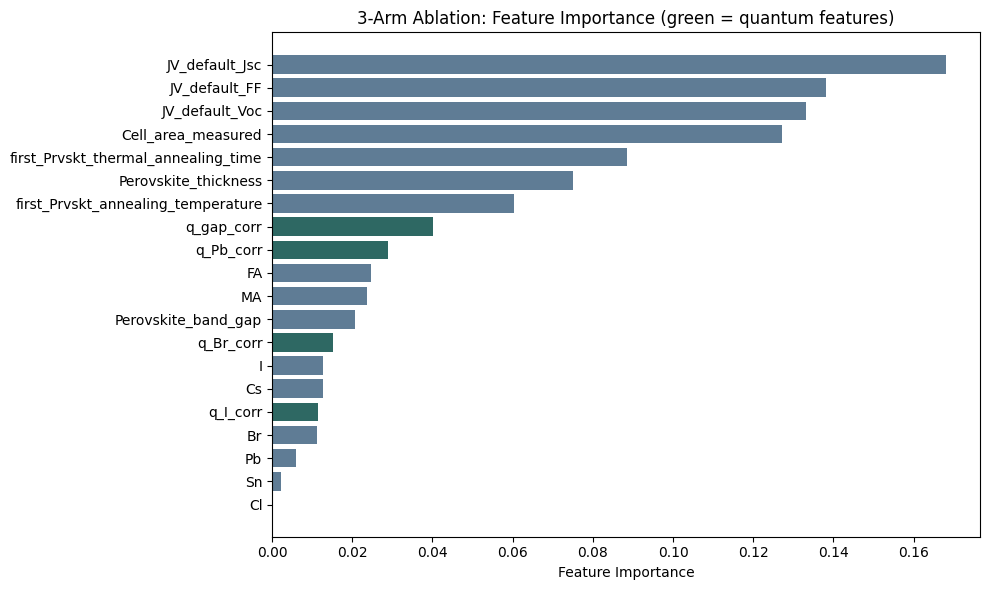

✅ Saved ablation_feature_importance.png


In [8]:
# Feature importance — does quantum reduce prediction variance?
importances = rf_quantum.feature_importances_
feature_names = list(X_quantum.columns)

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

quantum_importance = fi_df[fi_df['feature'].str.startswith('q_')]['importance'].sum()
total_importance = fi_df['importance'].sum()
print(f"Quantum feature importance: {quantum_importance/total_importance*100:.1f}% of total")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2E6863' if f.startswith('q_') else '#5F7C95' for f in fi_df['feature']]
ax.barh(fi_df['feature'], fi_df['importance'], color=colors)
ax.set_xlabel('Feature Importance')
ax.set_title('3-Arm Ablation: Feature Importance (green = quantum features)')
plt.tight_layout()
plt.savefig('ablation_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved ablation_feature_importance.png")

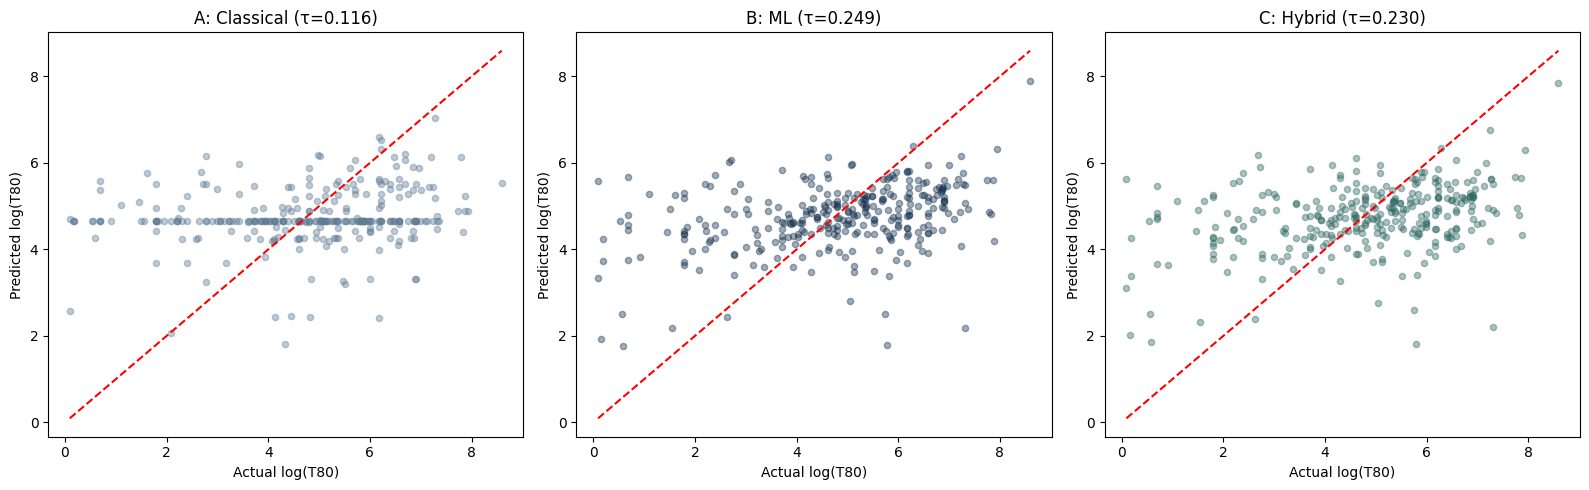

✅ Saved ablation_3arm_comparison.png


In [9]:
# 3-arm comparison plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, pred, label, tau, color in [
    (axes[0], pred_classical, 'A: Classical', tau_classical, '#5F7C95'),
    (axes[1], pred_ml, 'B: ML', tau_ml, '#16324F'),
    (axes[2], pred_quantum, 'C: Hybrid', tau_quantum, '#2E6863'),
]:
    ax.scatter(y_test, pred, alpha=0.4, s=20, color=color)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
    ax.set_xlabel('Actual log(T80)')
    ax.set_ylabel('Predicted log(T80)')
    ax.set_title(f'{label} (τ={tau:.3f})')

plt.tight_layout()
plt.savefig('ablation_3arm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved ablation_3arm_comparison.png")

In [10]:
# Save quantum-enhanced dataset for Notebook 03
X_quantum['Stability_PCE_T80'] = df['Stability_PCE_T80'].values
X_quantum['Perovskite_composition_long_form'] = df['Perovskite_composition_long_form'].values
X_quantum.to_csv("perovskite_with_quantum_features.csv", index=False)
print("✅ Saved quantum-enhanced dataset for next notebook")

✅ Saved quantum-enhanced dataset for next notebook
